In [4]:
#IMPORTING LIBRARIES
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path="/content/drive/MyDrive/Data Science Projects/California Housing Prediction /housing .csv"

In [6]:
df=pd.read_csv(path)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**DATA PREPROCESSING**

In [7]:
df.shape

(20640, 10)

In [8]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [9]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [11]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [12]:
#fill the null value
df["total_bedrooms"]=df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [13]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [14]:
#input feactures
"""longitude
latitude
housing_median_age
total_rooms
total_bedrooms
population
households
median_income
ocean_proximity	"""
#output features
"""median_house_value	"""
#there is only one colnums which have null values is total_bedrooms have 207 null values

#so we dont drop values because it is not aplicable because only one col have null values
# so we have other option use fillna() to fill the null values
# by using median of the total bedrooms
# we do not use mean because if there are some large value present in that particular col so means of this is also a large number which make data input large so it is not correct approach


'median_house_value\t'

In [15]:
df["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [16]:
# now ocean_proximity is string so convert it into number or int
df=pd.get_dummies(df,columns=["ocean_proximity"],dtype=int,drop_first=True)

In [17]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


**Get DummisTrap/ dummy variable trap**


*  "Dummy Variable Trap occurs when we create dummy variables for all categories of a feature, causing some variables to become highly correlated. This creates multicollinearity problems in regression models. We can avoid it by dropping one dummy variable from each categorical feature."
* When we convert categorical data into numbers using One-Hot Encoding (or get_dummies() in pandas), we create a new column for each category.

### *overcome this we drop one col using drop_first=True*



In [18]:
df.shape

(20640, 13)

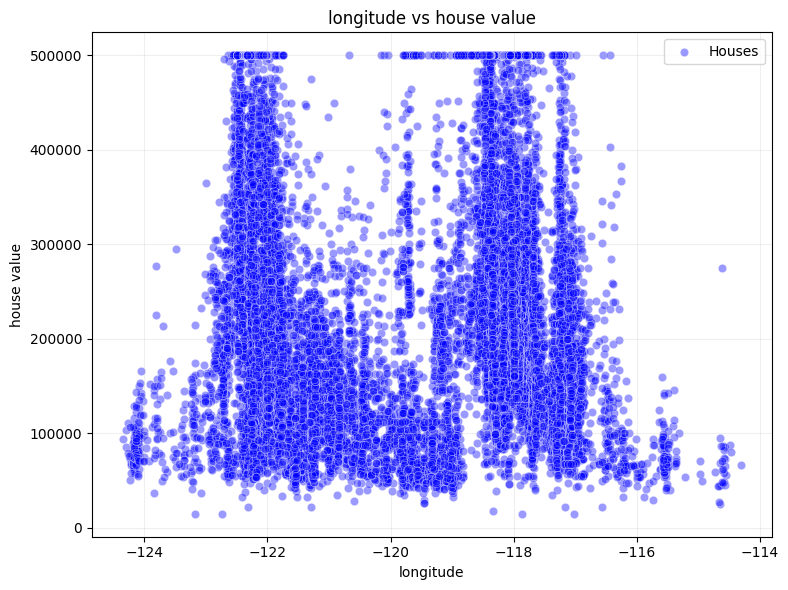

In [19]:
#feature selection using matplotlib and seabron
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["longitude"],y=df["median_house_value"],color="blue",alpha=0.4,label="Houses")
plt.title("longitude vs house value")
plt.xlabel("longitude")
plt.ylabel("house value")
plt.legend()
plt.grid(True,alpha=0.2)
plt.tight_layout()
plt.show()

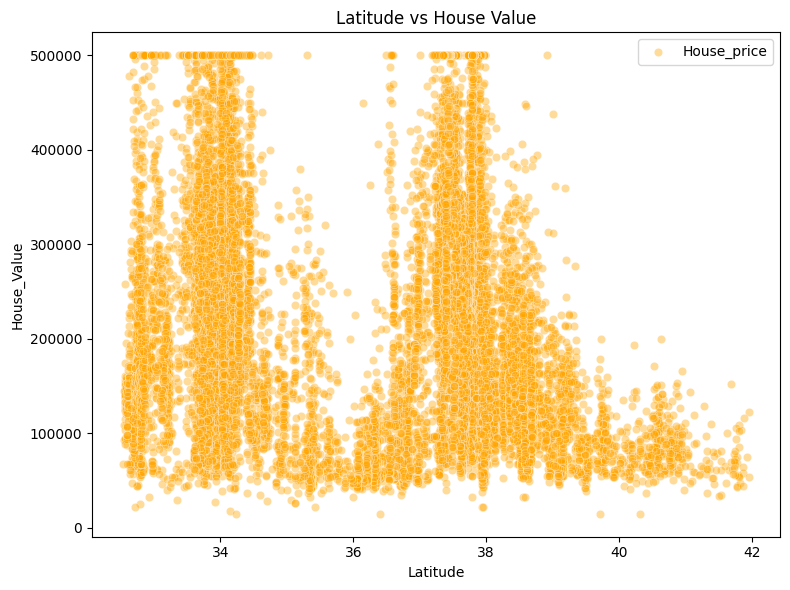

In [20]:
#latitude vs medain house value
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["latitude"],y=df["median_house_value"],color="orange",alpha=0.4,label="House_price")
plt.legend()
plt.title("Latitude vs House Value")
plt.xlabel("Latitude")
plt.ylabel("House_Value")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2466/1558843460.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


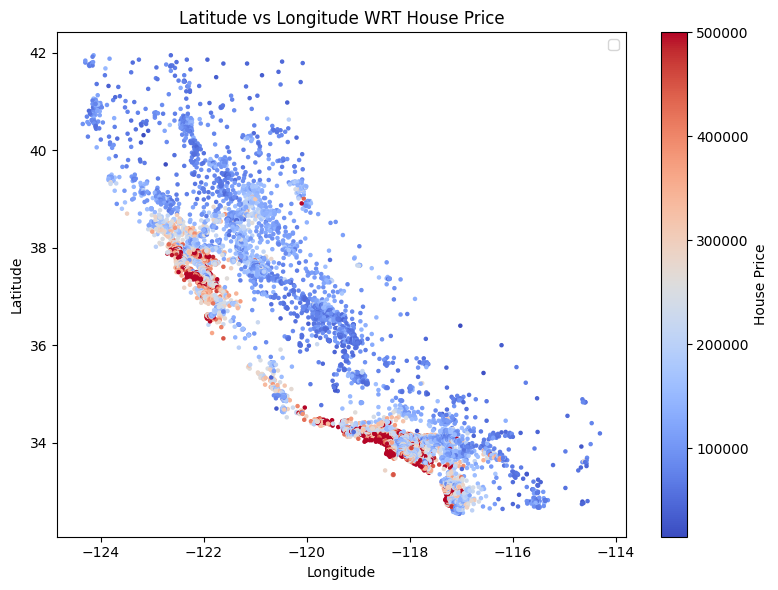

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(df["longitude"],df["latitude"],c=df["median_house_value"],s=5,cmap="coolwarm")
plt.legend()
plt.title("Latitude vs Longitude WRT House Price")
plt.colorbar(label="House Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

**This graph shows the location of houses based on their geographical coordinates**

* X-axis: Longitude
* Y-axis: Latitude
* Color: Median house price
* Each dot: Represents one house/block from the dataset.
* Interpretation:
* Red/warmer regions → Higher house prices.
* Blue/cooler regions → Lower house prices.

/tmp/ipykernel_2466/18621695.py:8: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


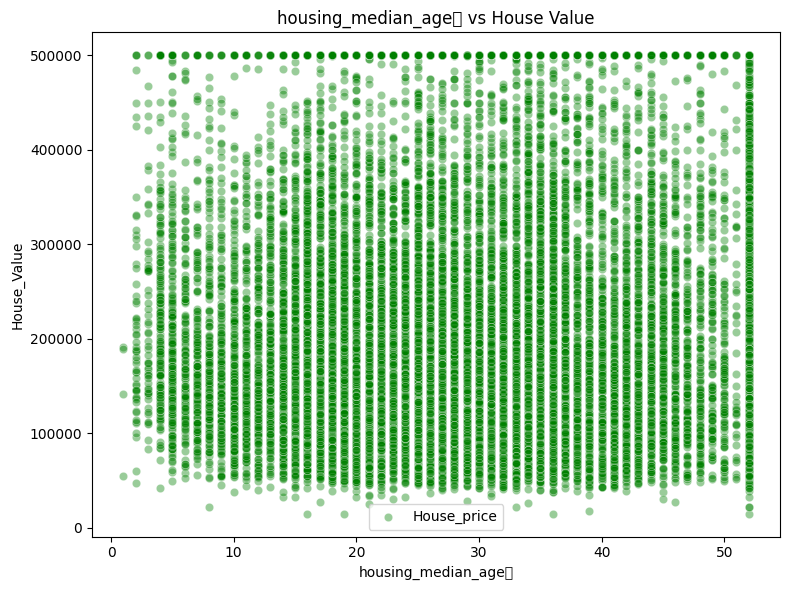

In [22]:
#housing median age vs housing median price its not relfect anything in price so we remove this feature
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["housing_median_age"],y=df["median_house_value"],color="green",alpha=0.4,label="House_price")
plt.legend()
plt.title("housing_median_age	 vs House Value")
plt.xlabel("housing_median_age	")
plt.ylabel("House_Value")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2466/2702312969.py:8: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


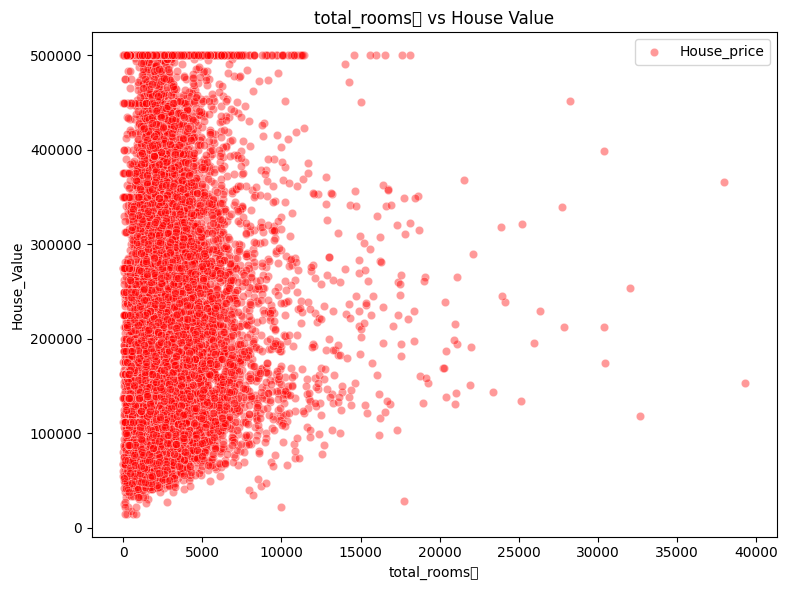

In [23]:
#total rooms vs house value
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["total_rooms"],y=df["median_house_value"],color="red",alpha=0.4,label="House_price")
plt.legend()
plt.title("total_rooms	 vs House Value")
plt.xlabel("total_rooms	")
plt.ylabel("House_Value")
plt.tight_layout()
plt.show()

**total room is not contributing in house price so we remove it**

/tmp/ipykernel_2466/2984525972.py:7: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


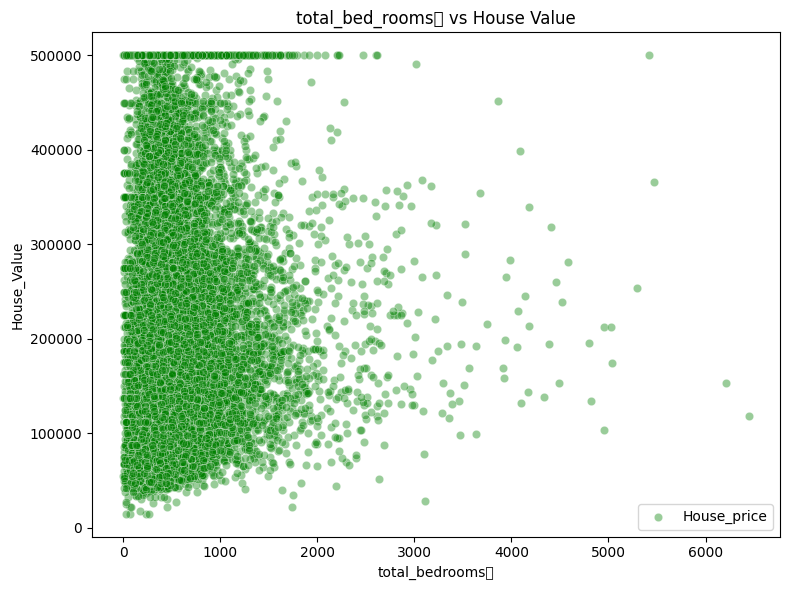

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["total_bedrooms"],y=df["median_house_value"],color="green",alpha=0.4,label="House_price")
plt.legend()
plt.title("total_bed_rooms	 vs House Value")
plt.xlabel("total_bedrooms	")
plt.ylabel("House_Value")
plt.tight_layout()
plt.show()

**Total bedrooms is alos not contributing so we remove this features from predication**

/tmp/ipykernel_2466/4077579863.py:7: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


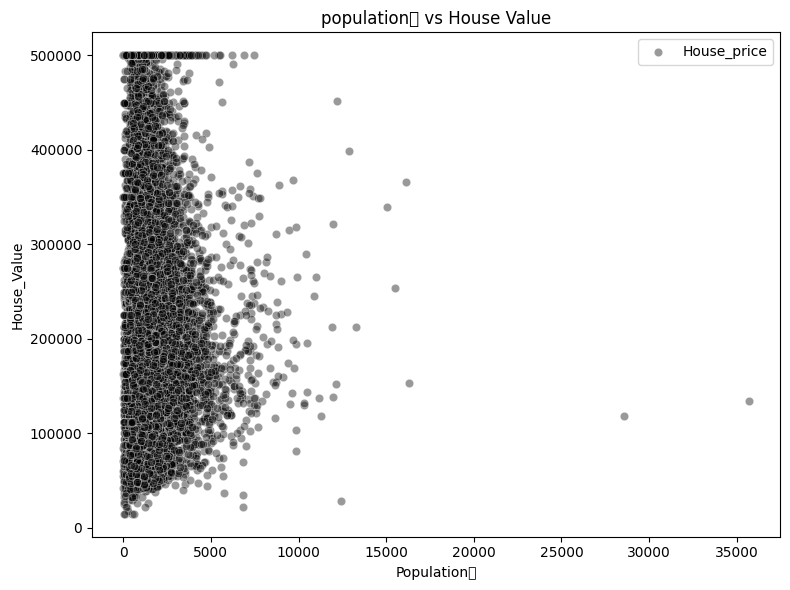

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["population"],y=df["median_house_value"],color="black",alpha=0.4,label="House_price")
plt.legend()
plt.title("population	 vs House Value")
plt.xlabel("Population	")
plt.ylabel("House_Value")
plt.tight_layout()
plt.show()

**Population also not contributing in the predction so we remove it from prediction features**

/tmp/ipykernel_2466/1897791646.py:8: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


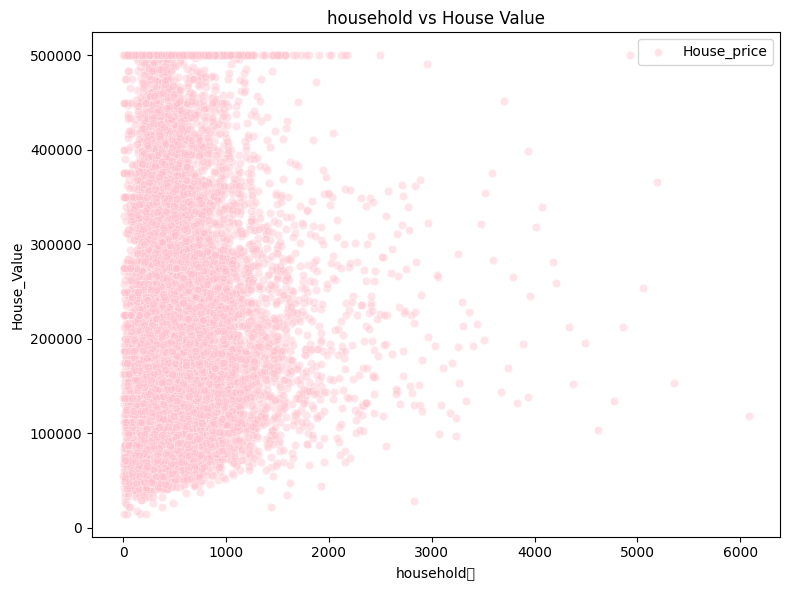

In [26]:
#households vs house price
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["households"],y=df["median_house_value"],color="pink",alpha=0.4,label="House_price")
plt.legend()
plt.title("household vs House Value")
plt.xlabel("household	")
plt.ylabel("House_Value")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2466/135795868.py:8: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


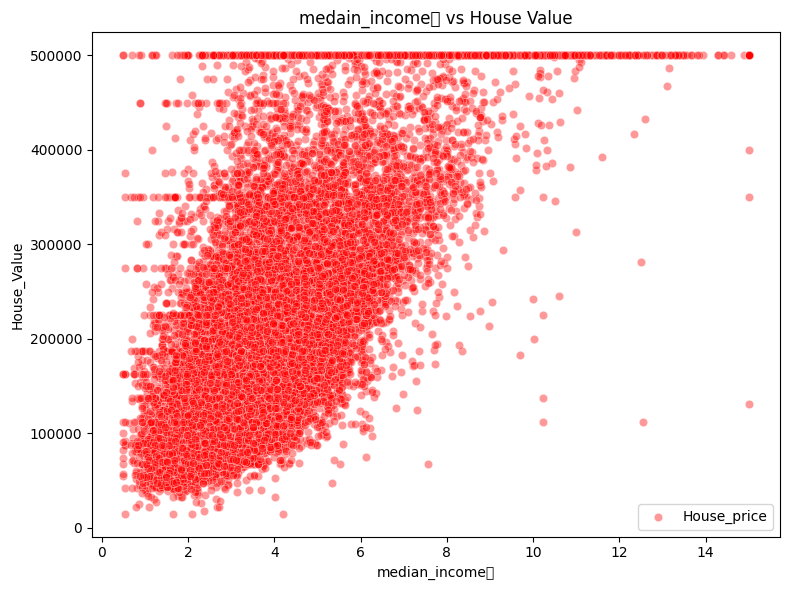

In [27]:
#median income vs house values
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["median_income"],y=df["median_house_value"],color="red",alpha=0.4,label="House_price")
plt.legend()
plt.title("medain_income	 vs House Value")
plt.xlabel("median_income	")
plt.ylabel("House_Value")
plt.tight_layout()
plt.show()


In [28]:
#corealtion always 0 and 1

#both increse postive
#one increse and ine dercrese coraltion -ve
#dont have any realtion so zero
"SO heatmap help us to find the corelation between the features"


'SO heatmap help us to find the corelation between the features'

Heatmap dikhata hai ki dataset ke columns ek-dusre se kitna related hain.

* df.corr() → har column pair ke beech correlation (-1 to 1) calculate karta hai
* sns.heatmap() → ye numbers ko color grid mein dikhata hai
* annot=True → har box mein number bhi dikhta hai
* cmap="coolwarm" → high positive = red, high negative = blue
* Baki lines (figsize, title, tight_layout, show) → sirf plot size, title aur display ke liye

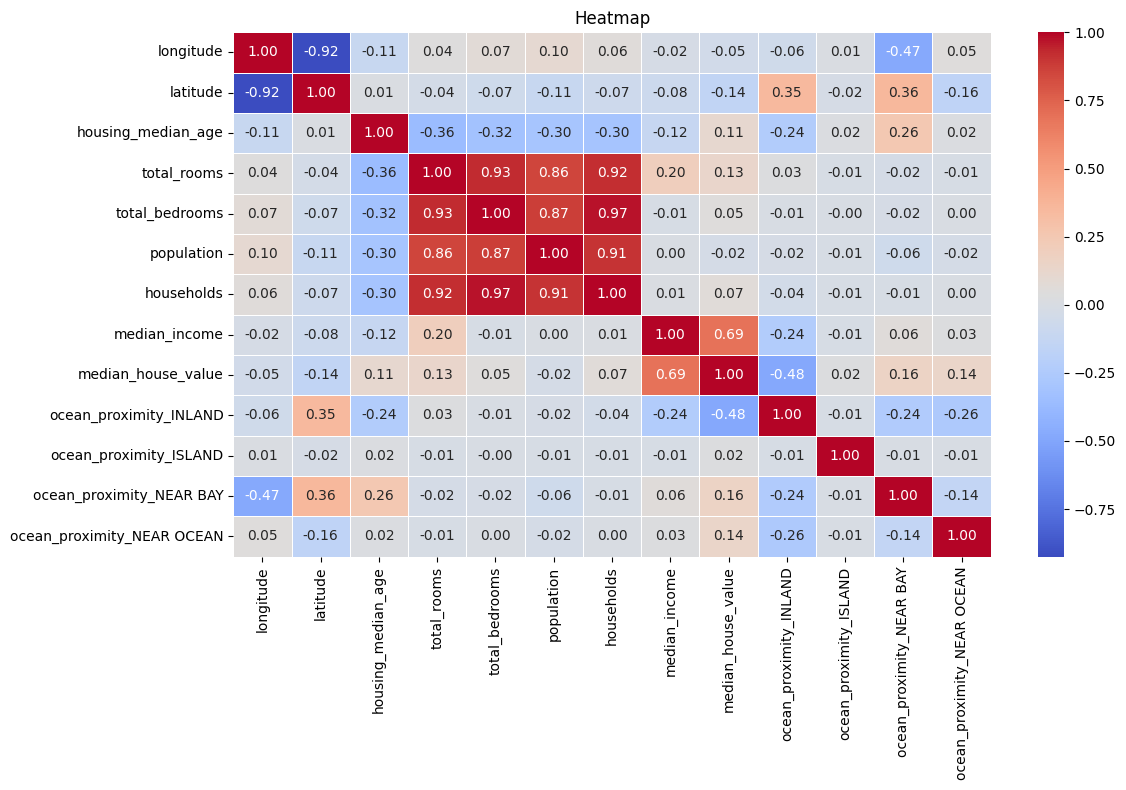

In [29]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,fmt=".2f",linewidth=0.5,cmap="coolwarm")
plt.title("Heatmap")
plt.tight_layout()
plt.show()

In [30]:
#define x and y
X=df.drop(columns=["median_house_value"])
y=df["median_house_value"]

In [31]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,0,0,1,0


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [33]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [34]:
X_train.shape

(16512, 12)

In [35]:
y_train.shape

(16512,)

In [36]:
y_test.shape

(4128,)

In [37]:
X_test.shape

(4128, 12)

In [38]:
#model training
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [39]:
#y prediction
y_pred=model.predict(X_test)
y_pred

array([ 54055.44889899, 124225.33893718, 255489.37949165, ...,
       439180.9834118 , 120797.55240621, 183386.04993584])

In [40]:
#mse
mse=mean_squared_error(y_test,y_pred)
mse

4908476721.156606

In [41]:
#mae
mae=mean_absolute_error(y_test,y_pred)
mae

50670.73824097229

In [42]:
#re score
r2=r2_score(y_test,y_pred)
r2

0.6254240620553614

In [43]:
#adjusted r2
r2 = 0.62
n = 20460
p = 13

r2adj = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
print(r2adj)


0.619758387948743


**"The Linear Regression model achieved an R² score of 0.625, indicating moderate predictive performance and serving as a strong baseline model."**

In [44]:
#now save the model
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [45]:
loaded_model = joblib.load("house_price_model.pkl")

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print(prediction)

[54055.44889898]
